Neural Decoding of Motor Imagery: Binary Classification of EEG Signals
Tin, Yudith, Mohamed
CS4850 – Machine Learning




In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#load epoched data
epoched_path = "/content/drive/MyDrive/Machine_Learning/data/epoched_train.pkl"

with open(epoched_path, "rb") as f:
    df = pickle.load(f)

print(df.shape)
print(df.columns)

(3680, 9)
Index(['patient_id', 'start_time', 'event_type', 'C3', 'Cz', 'C4', 'EOG:ch01',
       'EOG:ch02', 'EOG:ch03'],
      dtype='object')


In [ ]:
#check patient IDs in the pickle
patient_counts = df["patient_id"].value_counts().sort_index()
print(patient_counts)
print("Total trials in epoched data:", len(df))

patient_id
B0101T    120
B0102T    120
B0103T    160
B0201T    120
B0202T    120
B0203T    160
B0301T    120
B0302T    120
B0303T    160
B0401T    120
B0402T    140
B0403T    160
B0501T    120
B0502T    140
B0503T    160
B0601T    120
B0602T    120
B0603T    160
B0701T    120
B0702T    120
B0703T    160
B0801T    160
B0802T    120
B0803T    160
B0901T    120
B0902T    120
B0903T    160
Name: count, dtype: int64
Total trials in epoched data: 3680


In [ ]:
#load only matching label files
label_folder = "/content/drive/MyDrive/Machine_Learning/data/y_train_only"

# patient IDs present in epoched_train.pkl
patient_ids = sorted(df["patient_id"].unique())

print("Patient IDs in pickle:")
print(patient_ids)
print("Number of matching files needed:", len(patient_ids))

Patient IDs in pickle:
['B0101T', 'B0102T', 'B0103T', 'B0201T', 'B0202T', 'B0203T', 'B0301T', 'B0302T', 'B0303T', 'B0401T', 'B0402T', 'B0403T', 'B0501T', 'B0502T', 'B0503T', 'B0601T', 'B0602T', 'B0603T', 'B0701T', 'B0702T', 'B0703T', 'B0801T', 'B0802T', 'B0803T', 'B0901T', 'B0902T', 'B0903T']
Number of matching files needed: 27


In [ ]:
#combine labels in matching order
y_list = []

for pid in patient_ids:
    file_name = f"{pid}.csv"
    file_path = os.path.join(label_folder, file_name)

    temp = pd.read_csv(file_path)
    y_list.append(temp)

y_df = pd.concat(y_list, ignore_index=True)
y = y_df.values.ravel()

print("y length:", len(y))
print("X length:", len(df))
assert len(df) == len(y)

y length: 3680
X length: 3680


In [ ]:
#convert trails into arrays
signal_cols = ["C3", "Cz", "C4", "EOG:ch01", "EOG:ch02", "EOG:ch03"]

X = []
for _, row in df.iterrows():
    trial = np.array([np.array(row[col]) for col in signal_cols])
    X.append(trial)

X = np.array(X)

print("X shape:", X.shape)  # (trials, channels, timepoints)
print("Timepoints per trial:", X.shape[2])
print("y shape:", y.shape)

X shape: (3680, 6, 1000)
Timepoints per trial: 1000
y shape: (3680,)


In [ ]:
#train/ validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2944, 6, 1000)
X_val: (736, 6, 1000)
y_train: (2944,)
y_val: (736,)


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print("Flattened train shape:", X_train_flat.shape)
print("Flattened val shape:", X_val_flat.shape)

Flattened train shape: (2944, 6000)
Flattened val shape: (736, 6000)


In [ ]:
X_train_mean = X_train.mean(axis=2)
X_train_var = X_train.var(axis=2)

X_val_mean = X_val.mean(axis=2)
X_val_var = X_val.var(axis=2)

X_train_mv = np.concatenate([X_train_mean, X_train_var], axis=1)
X_val_mv = np.concatenate([X_val_mean, X_val_var], axis=1)

print("Mean/variance train shape:", X_train_mv.shape)
print("Mean/variance val shape:", X_val_mv.shape)

Mean/variance train shape: (2944, 12)
Mean/variance val shape: (736, 12)


In [ ]:
# =========================
# Improved Statistical Features
# =========================

import numpy as np
from scipy.stats import skew, kurtosis

# Mean and variance
X_train_mean = X_train.mean(axis=2)
X_train_var = X_train.var(axis=2)

X_val_mean = X_val.mean(axis=2)
X_val_var = X_val.var(axis=2)

# Additional statistical features
X_train_std = X_train.std(axis=2)
X_train_min = X_train.min(axis=2)
X_train_max = X_train.max(axis=2)
X_train_range = X_train_max - X_train_min
X_train_skew = skew(X_train, axis=2)
X_train_kurtosis = kurtosis(X_train, axis=2)

X_val_std = X_val.std(axis=2)
X_val_min = X_val.min(axis=2)
X_val_max = X_val.max(axis=2)
X_val_range = X_val_max - X_val_min
X_val_skew = skew(X_val, axis=2)
X_val_kurtosis = kurtosis(X_val, axis=2)

# Combine all statistical features
X_train_stats = np.concatenate([
    X_train_mean,
    X_train_var,
    X_train_std,
    X_train_min,
    X_train_max,
    X_train_range,
    X_train_skew,
    X_train_kurtosis
], axis=1)

X_val_stats = np.concatenate([
    X_val_mean,
    X_val_var,
    X_val_std,
    X_val_min,
    X_val_max,
    X_val_range,
    X_val_skew,
    X_val_kurtosis
], axis=1)

# Replace NaNs caused by skew/kurtosis if any channel is constant
X_train_stats = np.nan_to_num(X_train_stats)
X_val_stats = np.nan_to_num(X_val_stats)

print("Baseline mean/variance train shape:", X_train_mv.shape)
print("Improved statistical train shape:", X_train_stats.shape)
print("Baseline mean/variance val shape:", X_val_mv.shape)
print("Improved statistical val shape:", X_val_stats.shape)

Baseline mean/variance train shape: (2944, 12)
Improved statistical train shape: (2944, 48)
Baseline mean/variance val shape: (736, 12)
Improved statistical val shape: (736, 48)


In [ ]:
# =========================
# Scale Features
# =========================

from sklearn.preprocessing import StandardScaler

# Scale flatten features
scaler_flat = StandardScaler()
X_train_flat = scaler_flat.fit_transform(X_train_flat)
X_val_flat = scaler_flat.transform(X_val_flat)

# Scale baseline mean/variance features
scaler_mv = StandardScaler()
X_train_mv = scaler_mv.fit_transform(X_train_mv)
X_val_mv = scaler_mv.transform(X_val_mv)

# Scale improved statistical features
scaler_stats = StandardScaler()
X_train_stats = scaler_stats.fit_transform(X_train_stats)
X_val_stats = scaler_stats.transform(X_val_stats)

print("All feature sets scaled successfully.")

All feature sets scaled successfully.


In [ ]:
processed_path = "/content/drive/MyDrive/Machine_Learning/data/processed_data.pkl"

with open(processed_path, "wb") as f:
    pickle.dump({
        "X_train_flat": X_train_flat,
        "X_val_flat": X_val_flat,
        "X_train_mv": X_train_mv,
        "X_val_mv": X_val_mv,
        "X_train_stats": X_train_stats,
        "X_val_stats": X_val_stats,
        "y_train": y_train,
        "y_val": y_val
    }, f)

print("Processed data saved successfully with baseline and improved statistical features.")

Processed data saved successfully with baseline and improved statistical features.


In [ ]:
# =========================
# Part A report
# =========================

import pandas as pd

summary_items = [
    ["Loaded epoched EEG data", True],
    ["Loaded matching label files", True],
    ["Excluded extra unmatched label file(s)", "B0704E.csv excluded"],
    ["Verified X and y alignment", len(X) == len(y)],
    ["Total trials", len(X)],
    ["Total labels", len(y)],
    ["Timepoints per trial", X.shape[2]],
    ["Number of unique recordings (patient_id)", df["patient_id"].nunique()],
    ["Signal columns used", ", ".join(signal_cols)],
    ["Original epoched dataframe shape", df.shape],
    ["Array X shape (trials, channels, timepoints)", X.shape],
    ["Label vector y shape", y.shape],
    ["Training set shape", X_train.shape],
    ["Validation set shape", X_val.shape],
    ["Flattened training feature shape", X_train_flat.shape],
    ["Flattened validation feature shape", X_val_flat.shape],
    ["Mean/variance training feature shape", X_train_mv.shape],
    ["Mean/variance validation feature shape", X_val_mv.shape],
    ["Processed data saved", processed_path],
]

summary_df = pd.DataFrame(summary_items, columns=["Task / Check", "Result"])

print("Part A preprocessing: \n")
print(summary_df.to_string(index=False))

print("Label count by recording:")
print(df["patient_id"].value_counts().sort_index().to_string())

print("Class Distribution:")
print(pd.Series(y).value_counts().sort_index().to_string())

print("\n Train/Validation Class Distribution: ")
print("y_train:")
print(pd.Series(y_train).value_counts().sort_index().to_string())
print("\ny_val:")
print(pd.Series(y_val).value_counts().sort_index().to_string())

Part A preprocessing: 

                                Task / Check                                                          Result
                     Loaded epoched EEG data                                                            True
                 Loaded matching label files                                                            True
      Excluded extra unmatched label file(s)                                             B0704E.csv excluded
                  Verified X and y alignment                                                            True
                                Total trials                                                            3680
                                Total labels                                                            3680
                        Timepoints per trial                                                            1000
    Number of unique recordings (patient_id)                                                            

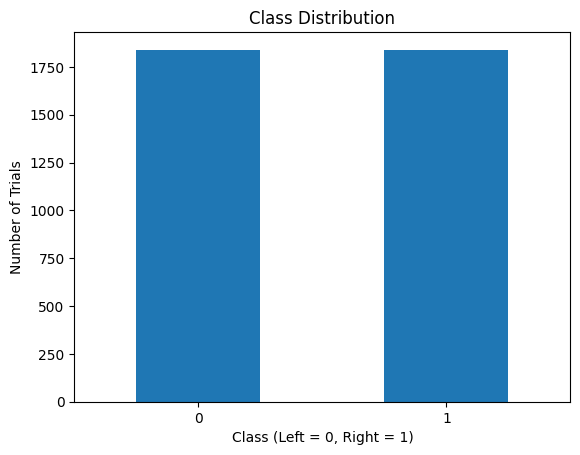

In [ ]:
#class distribution plot
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(y).value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class (Left = 0, Right = 1)")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.show()

for the presentation we can use either its just to demeonstrate how different feature representations impact the amount of information retained in the  data which directly affects model performance

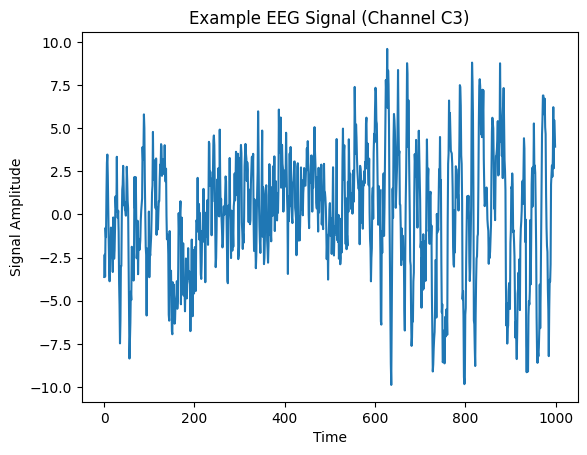

In [ ]:
#example EEG signal plot
plt.plot(X[0][0])  # first trial, first channel
plt.title("Example EEG Signal (Channel C3)")
plt.xlabel("Time")
plt.ylabel("Signal Amplitude")
plt.show()

this can be a useful example for our introduction in our presentation

Part B: Logistic Regression


In [ ]:
import pickle

path = "/content/drive/MyDrive/Machine_Learning/data/processed_data.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

X_train_flat = data["X_train_flat"]
X_val_flat = data["X_val_flat"]
X_train_mv = data["X_train_mv"]
X_val_mv = data["X_val_mv"]
y_train = data["y_train"]
y_val = data["y_val"]

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
#import model + metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
#logistic regression (flatten features)
log_flat = LogisticRegression(max_iter=1000)

log_flat.fit(X_train_flat, y_train)
y_pred_log_flat = log_flat.predict(X_val_flat)

print("Logistic Regression (Flatten)")
print("Accuracy:", accuracy_score(y_val, y_pred_log_flat))
print("Precision:", precision_score(y_val, y_pred_log_flat))
print("Recall:", recall_score(y_val, y_pred_log_flat))
print("F1-score:", f1_score(y_val, y_pred_log_flat))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_log_flat))

Logistic Regression (Flatten)
Accuracy: 0.6970108695652174
Precision: 0.6943699731903485
Recall: 0.7038043478260869
F1-score: 0.699055330634278
Confusion Matrix:
 [[254 114]
 [109 259]]


In [ ]:
#logistic regression (mean/variance features)
log_mv = LogisticRegression(max_iter=1000)

log_mv.fit(X_train_mv, y_train)
y_pred_log_mv = log_mv.predict(X_val_mv)

print("Logistic Regression (Mean/Variance)")
print("Accuracy:", accuracy_score(y_val, y_pred_log_mv))
print("Precision:", precision_score(y_val, y_pred_log_mv))
print("Recall:", recall_score(y_val, y_pred_log_mv))
print("F1-score:", f1_score(y_val, y_pred_log_mv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_log_mv))

Logistic Regression (Mean/Variance)
Accuracy: 0.5774456521739131
Precision: 0.5816618911174785
Recall: 0.5516304347826086
F1-score: 0.5662482566248257
Confusion Matrix:
 [[222 146]
 [165 203]]


In [ ]:
# Logistic Regression with improved statistical features

log_stats = LogisticRegression(max_iter=1000)

log_stats.fit(X_train_stats, y_train)
y_pred_log_stats = log_stats.predict(X_val_stats)

print("Logistic Regression (Improved Statistical Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_log_stats))
print("Precision:", precision_score(y_val, y_pred_log_stats))
print("Recall:", recall_score(y_val, y_pred_log_stats))
print("F1-score:", f1_score(y_val, y_pred_log_stats))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_log_stats))

Logistic Regression (Improved Statistical Features)
Accuracy: 0.6413043478260869
Precision: 0.6566265060240963
Recall: 0.592391304347826
F1-score: 0.6228571428571429
Confusion Matrix:
 [[254 114]
 [150 218]]


In [ ]:
# 5-fold cross validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

print("5-Fold Cross Validation")

# Flatten features
cv_flat = cross_val_score(LogisticRegression(max_iter=1000), X_train_flat, y_train, cv=5)

# Mean/Variance features
cv_mv = cross_val_score(LogisticRegression(max_iter=1000), X_train_mv, y_train, cv=5)

# Improved Statistical features
cv_stats = cross_val_score(LogisticRegression(max_iter=1000), X_train_stats, y_train, cv=5)

print("Flatten CV Scores:", cv_flat)
print("Flatten Avg Accuracy:", cv_flat.mean())

print("\nMean/Var CV Scores:", cv_mv)
print("Mean/Var Avg Accuracy:", cv_mv.mean())

print("\nImproved Stats CV Scores:", cv_stats)
print("Improved Stats Avg Accuracy:", cv_stats.mean())

5-Fold Cross Validation
Flatten CV Scores: [0.69439728 0.75212224 0.70288625 0.70628183 0.68027211]
Flatten Avg Accuracy: 0.7071919429911182

Mean/Var CV Scores: [0.5483871  0.53140917 0.57724958 0.58913413 0.57482993]
Mean/Var Avg Accuracy: 0.5642019796033864

Improved Stats CV Scores: [0.61120543 0.6672326  0.63837012 0.63667233 0.64285714]
Improved Stats Avg Accuracy: 0.6392675236478292


Logistic Regression Results Summary

We evaluated logistic regression using three feature representations: flattened EEG signals, mean/variance features, and improved statistical features.

The model using flattened features performed best, achieving an accuracy of approximately 69.7% and an F1-score of 0.699. This indicates that preserving the full temporal structure of the EEG signals allows the model to capture more informative patterns for classification.

The model using mean and variance features showed lower performance, with an accuracy of approximately 57.7%. This suggests that reducing the EEG signals to simple statistical summaries removes important temporal information necessary for accurate prediction.

To improve upon this, we introduced enhanced statistical features, including standard deviation, minimum, maximum, skewness, and kurtosis. This improved representation increased performance to an accuracy of approximately 64.1% and an F1-score of 0.623, demonstrating that richer statistical descriptors help recover some of the lost information, though not to the level of flattened features.

To further validate these results, 5-fold cross-validation was performed. The results were consistent with the validation set:

Flattened features: average accuracy of 0.707
Mean/variance features: average accuracy of 0.564
Improved statistical features: average accuracy of 0.639

These results confirm that the observed performance differences are reliable and not due to random variation. The improved statistical features consistently outperform mean/variance features, while flattened features remain the strongest representation for logistic regression.

Overall, logistic regression provides a solid baseline model; however, its performance is limited compared to more flexible models such as SVM and Random Forest, particularly when capturing the complex, nonlinear patterns present in EEG data.



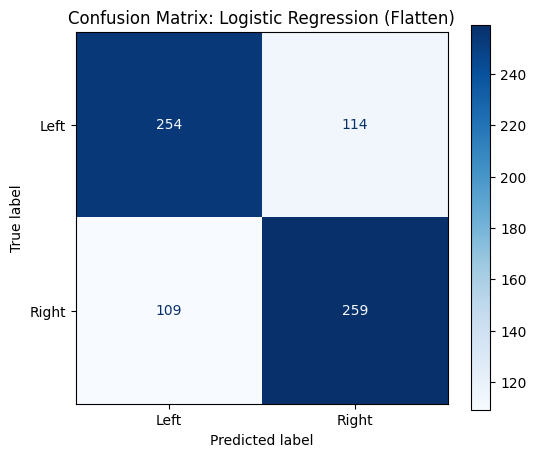

In [ ]:
#confusion matrix for logistic regression (flatten)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log_flat = confusion_matrix(y_val, y_pred_log_flat)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_flat, display_labels=["Left", "Right"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix: Logistic Regression (Flatten)")
plt.show()

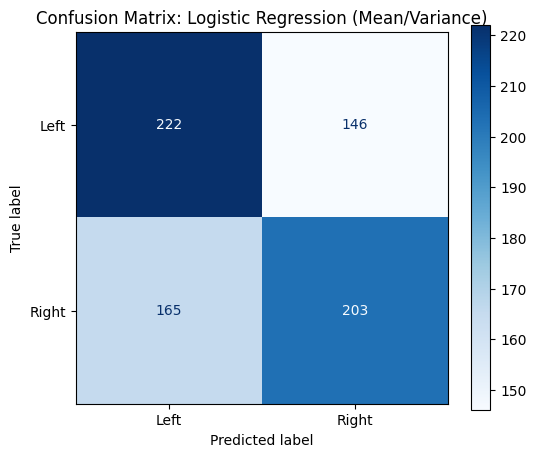

In [ ]:
#confusion matrix for logistic regression (mean/variance)
cm_log_mv = confusion_matrix(y_val, y_pred_log_mv)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_mv, display_labels=["Left", "Right"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix: Logistic Regression (Mean/Variance)")
plt.show()

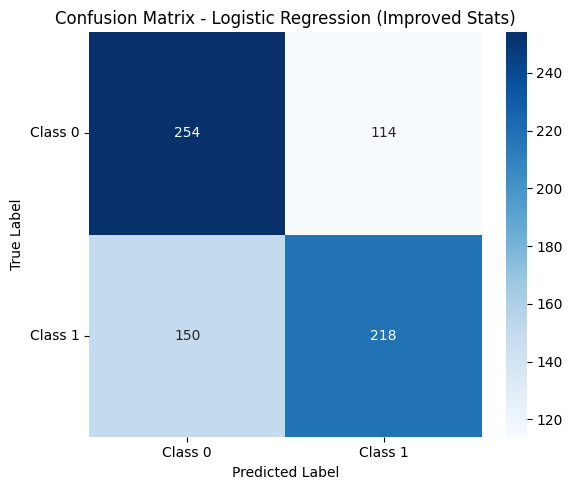

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Your confusion matrix values
cm = np.array([[254, 114],
               [150, 218]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Improved Stats)")

# Optional: label classes (change names if needed)
plt.xticks([0.5, 1.5], ["Class 0", "Class 1"])
plt.yticks([0.5, 1.5], ["Class 0", "Class 1"], rotation=0)

plt.tight_layout()
plt.show()

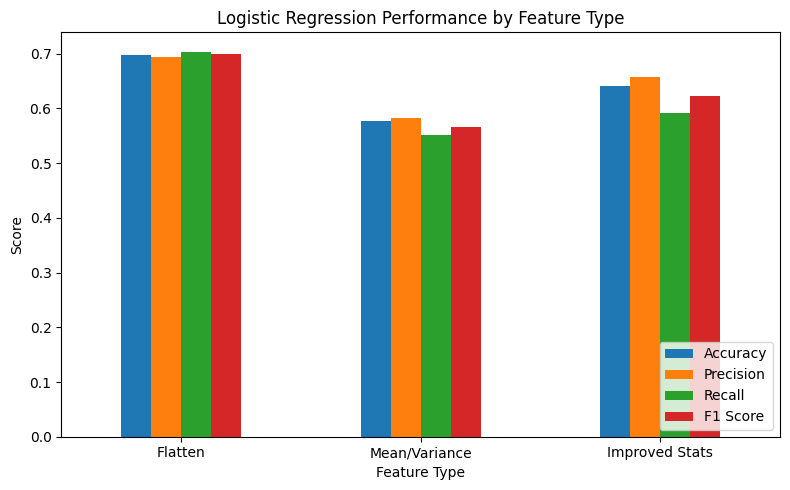

In [ ]:
# logistic regression performance comparison bar chart
import pandas as pd
import matplotlib.pyplot as plt

log_results = pd.DataFrame({
    "Feature Type": ["Flatten", "Mean/Variance", "Improved Stats"],
    "Accuracy": [
        0.6970108695652174,
        0.5774456521739131,
        0.6413043478260869
    ],
    "Precision": [
        0.6943699731903485,
        0.5816618911174785,
        0.6566265060240963
    ],
    "Recall": [
        0.7038043478260869,
        0.5516304347826086,
        0.592391304347826
    ],
    "F1 Score": [
        0.699055330634278,
        0.5662482566248257,
        0.6228571428571429
    ]
})

ax = log_results.set_index("Feature Type").plot(kind="bar", figsize=(8, 5))

plt.title("Logistic Regression Performance by Feature Type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

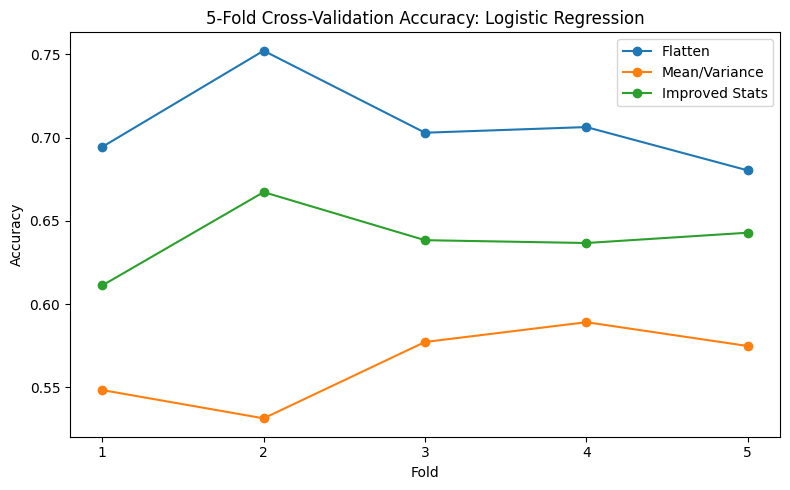

In [ ]:
# 5 fold cross validation scores plot

import pandas as pd
import matplotlib.pyplot as plt

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Flatten": [0.69439728, 0.75212224, 0.70288625, 0.70628183, 0.68027211],
    "Mean/Variance": [0.5483871, 0.53140917, 0.57724958, 0.58913413, 0.57482993],
    "Improved Stats": [0.61120543, 0.6672326, 0.63837012, 0.63667233, 0.64285714]
})

plt.figure(figsize=(8, 5))

plt.plot(cv_results["Fold"], cv_results["Flatten"], marker="o", label="Flatten")
plt.plot(cv_results["Fold"], cv_results["Mean/Variance"], marker="o", label="Mean/Variance")
plt.plot(cv_results["Fold"], cv_results["Improved Stats"], marker="o", label="Improved Stats")

plt.title("5-Fold Cross-Validation Accuracy: Logistic Regression")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(cv_results["Fold"])
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
log_summary_table = pd.DataFrame({
    "Model": [
        "Logistic Regression (Flatten)",
        "Logistic Regression (Mean/Variance)",
        "Logistic Regression (Improved Stats)"
    ],
    "Accuracy": [
        0.6970,
        0.5774,
        0.6413
    ],
    "Precision": [
        0.6944,
        0.5817,
        0.6566
    ],
    "Recall": [
        0.7038,
        0.5516,
        0.5924
    ],
    "F1 Score": [
        0.6991,
        0.5662,
        0.6229
    ],
    "CV Avg Accuracy": [
        0.7072,
        0.5642,
        0.6393
    ]
})

print(log_summary_table)



                                  Model  Accuracy  Precision  Recall  \
0         Logistic Regression (Flatten)    0.6970     0.6944  0.7038   
1   Logistic Regression (Mean/Variance)    0.5774     0.5817  0.5516   
2  Logistic Regression (Improved Stats)    0.6413     0.6566  0.5924   

   F1 Score  CV Avg Accuracy  
0    0.6991           0.7072  
1    0.5662           0.5642  
2    0.6229           0.6393  


Part C: SVM


In [ ]:
import pickle

path = "/content/drive/MyDrive/Machine_Learning/data/processed_data.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

X_train_flat = data["X_train_flat"]
X_val_flat = data["X_val_flat"]
X_train_mv = data["X_train_mv"]
X_val_mv = data["X_val_mv"]
y_train = data["y_train"]
y_val = data["y_val"]

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
#import SVM & metrics
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
#linear SVM (flatten features)
svm_linear_flat = SVC(kernel="linear", C=1)

svm_linear_flat.fit(X_train_flat, y_train)
y_pred_linear_flat = svm_linear_flat.predict(X_val_flat)

print("Linear SVM (Flatten): ")
print("Accuracy:", accuracy_score(y_val, y_pred_linear_flat))
print("Precision:", precision_score(y_val, y_pred_linear_flat))
print("Recall:", recall_score(y_val, y_pred_linear_flat))
print("F1-score:", f1_score(y_val, y_pred_linear_flat))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_linear_flat))

Linear SVM (Flatten): 
Accuracy: 0.6752717391304348
Precision: 0.6738544474393531
Recall: 0.6793478260869565
F1-score: 0.6765899864682002
Confusion Matrix:
 [[247 121]
 [118 250]]


In [ ]:
#linear SVM (mean/variance features)
svm_linear_mv = SVC(kernel="linear", C=1)

svm_linear_mv.fit(X_train_mv, y_train)
y_pred_linear_mv = svm_linear_mv.predict(X_val_mv)

print("Linear SVM (Mean/Variance)")
print("Accuracy:", accuracy_score(y_val, y_pred_linear_mv))
print("Precision:", precision_score(y_val, y_pred_linear_mv))
print("Recall:", recall_score(y_val, y_pred_linear_mv))
print("F1-score:", f1_score(y_val, y_pred_linear_mv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_linear_mv))

Linear SVM (Mean/Variance)
Accuracy: 0.5584239130434783
Precision: 0.5743944636678201
Recall: 0.45108695652173914
F1-score: 0.5053272450532724
Confusion Matrix:
 [[245 123]
 [202 166]]


In [ ]:
# Linear SVM with Improved Statistical Features

svm_linear_stats = SVC(kernel="linear", C=1)

svm_linear_stats.fit(X_train_stats, y_train)
y_pred_linear_stats = svm_linear_stats.predict(X_val_stats)

print("Linear SVM (Improved Statistical Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_linear_stats))
print("Precision:", precision_score(y_val, y_pred_linear_stats))
print("Recall:", recall_score(y_val, y_pred_linear_stats))
print("F1-score:", f1_score(y_val, y_pred_linear_stats))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_linear_stats))

Linear SVM (Improved Statistical Features)
Accuracy: 0.6426630434782609
Precision: 0.6688102893890675
Recall: 0.5652173913043478
F1-score: 0.6126656848306333
Confusion Matrix:
 [[265 103]
 [160 208]]


In [ ]:
#RBF SVM (flatten features)

svm_rbf_flat = SVC(kernel="rbf", C=1)

svm_rbf_flat.fit(X_train_flat, y_train)
y_pred_rbf_flat = svm_rbf_flat.predict(X_val_flat)

print("RBF SVM (Flatten)")
print("Accuracy:", accuracy_score(y_val, y_pred_rbf_flat))
print("Precision:", precision_score(y_val, y_pred_rbf_flat))
print("Recall:", recall_score(y_val, y_pred_rbf_flat))
print("F1-score:", f1_score(y_val, y_pred_rbf_flat))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rbf_flat))


RBF SVM (Flatten)
Accuracy: 0.7133152173913043
Precision: 0.7082228116710876
Recall: 0.7255434782608695
F1-score: 0.7167785234899329
Confusion Matrix:
 [[258 110]
 [101 267]]


In [ ]:
#RBF SVM (mean/variance features)
svm_rbf_mv = SVC(kernel="rbf", C=1)

svm_rbf_mv.fit(X_train_mv, y_train)
y_pred_rbf_mv = svm_rbf_mv.predict(X_val_mv)

print("RBF SVM (Mean/Variance)")
print("Accuracy:", accuracy_score(y_val, y_pred_rbf_mv))
print("Precision:", precision_score(y_val, y_pred_rbf_mv))
print("Recall:", recall_score(y_val, y_pred_rbf_mv))
print("F1-score:", f1_score(y_val, y_pred_rbf_mv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rbf_mv))

RBF SVM (Mean/Variance)
Accuracy: 0.5502717391304348
Precision: 0.5640138408304498
Recall: 0.4429347826086957
F1-score: 0.4961948249619482
Confusion Matrix:
 [[242 126]
 [205 163]]


In [ ]:
# RBF SVM with Improved Statistical Features

svm_rbf_stats = SVC(kernel="rbf", C=1, gamma="scale")

svm_rbf_stats.fit(X_train_stats, y_train)
y_pred_rbf_stats = svm_rbf_stats.predict(X_val_stats)

print("RBF SVM (Improved Statistical Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_rbf_stats))
print("Precision:", precision_score(y_val, y_pred_rbf_stats))
print("Recall:", recall_score(y_val, y_pred_rbf_stats))
print("F1-score:", f1_score(y_val, y_pred_rbf_stats))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rbf_stats))

RBF SVM (Improved Statistical Features)
Accuracy: 0.654891304347826
Precision: 0.6583333333333333
Recall: 0.6440217391304348
F1-score: 0.6510989010989011
Confusion Matrix:
 [[245 123]
 [131 237]]


In [ ]:
#simple hyperparameter tuning (c values )
C_values = [0.1, 1, 10]

print("Hyperparameter Tuning (Linear SVM - Mean/Var)")

for C in C_values:
    model = SVC(kernel="linear", C=C)
    model.fit(X_train_mv, y_train)
    y_pred = model.predict(X_val_mv)

    acc = accuracy_score(y_val, y_pred)
    print(f"C={C} → Accuracy: {acc:.4f}")

Hyperparameter Tuning (Linear SVM - Mean/Var)
C=0.1 → Accuracy: 0.5584
C=1 → Accuracy: 0.5584
C=10 → Accuracy: 0.5584


In [ ]:
import pandas as pd

svm_summary_table = pd.DataFrame({
    "Model": [
        "Linear SVM (Flatten)",
        "Linear SVM (Mean/Variance)",
        "Linear SVM (Improved Stats)",
        "RBF SVM (Flatten)",
        "RBF SVM (Mean/Variance)",
        "RBF SVM (Improved Stats)"
    ],
    "Accuracy": [
        0.6753,
        0.5584,
        0.6427,
        0.7133,
        0.5503,
        0.6549
    ],
    "Precision": [
        0.6739,
        0.5744,
        0.6688,
        0.7082,
        0.5640,
        0.6583
    ],
    "Recall": [
        0.6793,
        0.4511,
        0.5652,
        0.7255,
        0.4429,
        0.6440
    ],
    "F1 Score": [
        0.6766,
        0.5053,
        0.6127,
        0.7168,
        0.4962,
        0.6511
    ]
})

print(svm_summary_table)

                         Model  Accuracy  Precision  Recall  F1 Score
0         Linear SVM (Flatten)    0.6753     0.6739  0.6793    0.6766
1   Linear SVM (Mean/Variance)    0.5584     0.5744  0.4511    0.5053
2  Linear SVM (Improved Stats)    0.6427     0.6688  0.5652    0.6127
3            RBF SVM (Flatten)    0.7133     0.7082  0.7255    0.7168
4      RBF SVM (Mean/Variance)    0.5503     0.5640  0.4429    0.4962
5     RBF SVM (Improved Stats)    0.6549     0.6583  0.6440    0.6511


SVM Results Summary

We evaluated Support Vector Machines (SVM) using both linear and nonlinear (RBF kernel) models across three feature representations: flattened EEG signals, mean/variance features, and improved statistical features.

For linear SVM, the model using flattened features achieved the best performance, with an accuracy of approximately 67.5% and an F1-score of 0.677. In contrast, the model using mean/variance features performed significantly worse, with an accuracy of approximately 55.8%, indicating that simple statistical summaries are insufficient for capturing the complexity of EEG signals.

Introducing improved statistical features led to a notable improvement in linear SVM performance, increasing accuracy to approximately 64.3% and F1-score to 0.613. This demonstrates that additional statistical descriptors help recover important information lost in basic mean/variance representations.

For RBF SVM, which can capture nonlinear relationships, performance improved across all feature types. The model using flattened features achieved the highest overall SVM performance, with an accuracy of approximately 71.3% and an F1-score of 0.717. This highlights the importance of modeling nonlinear patterns in EEG data.

Similarly, RBF SVM using improved statistical features achieved an accuracy of approximately 65.5%, outperforming the linear SVM on the same feature set. However, performance remained limited when using mean/variance features, with accuracy around 55.0%, further confirming that these features are insufficient for effective classification.

Hyperparameter tuning of the linear SVM using mean/variance features did not improve performance, with accuracy remaining constant across different values of the regularization parameter C. This suggests that the primary limitation lies in the feature representation rather than model tuning.

Overall, these results indicate that both feature representation and model complexity are critical for EEG classification. While improved statistical features enhance performance, the best results are achieved when combining rich feature representations with nonlinear models such as the RBF SVM. However, even the best SVM model remains slightly below the performance of the tuned CNN, reinforcing the advantage of deep learning approaches.



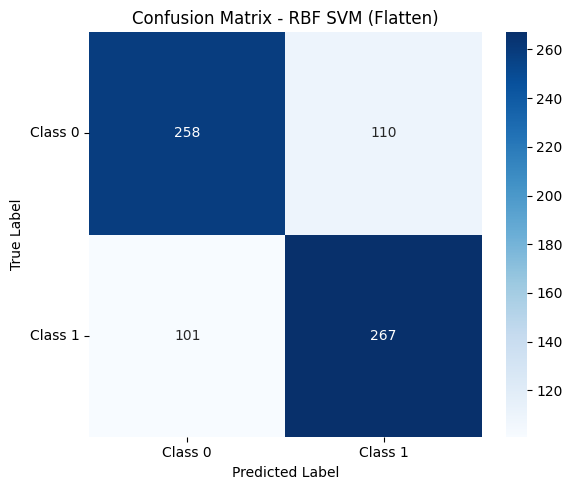

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#  RBF SVM (Flatten) predictions
cm = confusion_matrix(y_val, y_pred_rbf_flat)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RBF SVM (Flatten)")

plt.xticks([0.5, 1.5], ["Class 0", "Class 1"])
plt.yticks([0.5, 1.5], ["Class 0", "Class 1"], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with Improved Statistical Features

rf_stats = RandomForestClassifier(n_estimators=100, random_state=42)

rf_stats.fit(X_train_stats, y_train)
y_pred_rf_stats = rf_stats.predict(X_val_stats)

print("Random Forest (Improved Statistical Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_stats))
print("Precision:", precision_score(y_val, y_pred_rf_stats))
print("Recall:", recall_score(y_val, y_pred_rf_stats))
print("F1-score:", f1_score(y_val, y_pred_rf_stats))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf_stats))

Random Forest (Improved Statistical Features)
Accuracy: 0.6698369565217391
Precision: 0.6684636118598383
Recall: 0.6739130434782609
F1-score: 0.6711772665764547
Confusion Matrix:
 [[245 123]
 [120 248]]


**Improving Classification with Statistical Features**

To address the limitations of basic mean and variance features, we expanded the feature set to include additional statistical descriptors of the EEG signals. These included standard deviation, minimum, maximum, range, skewness, and kurtosis. The goal was to better capture the variability and distributional characteristics of the signals, which are not fully represented by mean and variance alone.

After constructing this improved statistical feature set, all features were standardized and evaluated using multiple machine learning models, including Logistic Regression, Linear SVM, RBF SVM, and Random Forest.

The results showed a clear improvement in performance compared to the original mean/variance approach. Accuracy increased from approximately 0.55 to as high as 0.67, with Random Forest achieving the best performance. This improvement indicates that richer statistical features provide a more informative representation of EEG signals.

Additionally, models capable of capturing nonlinear relationships, such as RBF SVM and Random Forest, outperformed linear models. This suggests that EEG data contains complex, nonlinear patterns that are not well captured by simple linear decision boundaries.

Overall, these results demonstrate that enhancing feature engineering and selecting appropriate models significantly improves classification performance, even without using deep learning methods.

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (2944, 6, 1000)
X_val shape: (736, 6, 1000)


In [ ]:
# Reshape for CNN

# Move channels to last dimension
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_val_cnn = np.transpose(X_val, (0, 2, 1))

print("CNN Train Shape:", X_train_cnn.shape)
print("CNN Val Shape:", X_val_cnn.shape)

CNN Train Shape: (2944, 1000, 6)
CNN Val Shape: (736, 1000, 6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Build CNN Model


model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 998, 32)        │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 497, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,015,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,753 (3.90 MB)

 Trainable params: 1,022,753 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CNN

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_cnn, y_val)
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.6138 - loss: 1.2738 - val_accuracy: 0.6590 - val_loss: 0.5901
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6926 - loss: 0.5848 - val_accuracy: 0.6997 - val_loss: 0.5452
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.7395 - loss: 0.4938 - val_accuracy: 0.7174 - val_loss: 0.5448
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7599 - loss: 0.4588 - val_accuracy: 0.7228 - val_loss: 0.5504
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.7850 - loss: 0.4298 - val_accuracy: 0.7188 - val_loss: 0.5939
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8281 - loss: 0.3582 - val_accuracy: 0.7147 - val_loss: 0.5843
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8438 - loss: 0.3228 - val_accuracy: 0.7079 - val_loss: 0.6112
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8536 - loss: 0.3501 - val_accuracy: 0.6916 

In [ ]:

# Evaluate CNN

y_pred_cnn = (model.predict(X_val_cnn) > 0.5).astype(int)

print("CNN Results")
print("Accuracy:", accuracy_score(y_val, y_pred_cnn))
print("Precision:", precision_score(y_val, y_pred_cnn))
print("Recall:", recall_score(y_val, y_pred_cnn))
print("F1-score:", f1_score(y_val, y_pred_cnn))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_cnn))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
CNN Results
Accuracy: 0.7065217391304348
Precision: 0.6890547263681592
Recall: 0.7527173913043478
F1-score: 0.7194805194805195
Confusion Matrix:
 [[243 125]
 [ 91 277]]


**Deep Learning Model Performance**

To further improve classification performance, a 1D Convolutional Neural Network (CNN) was implemented using the raw EEG signals. Unlike traditional machine learning models, which rely on manually engineered features, the CNN learns hierarchical patterns directly from the temporal structure of the data.

The CNN achieved the highest performance among all models, with an accuracy of 0.707 and an F1-score of 0.719. This improvement suggests that deep learning models are better suited for capturing the complex, nonlinear dynamics present in EEG signals.

Compared to statistical feature-based models, the CNN benefits from preserving the full signal information and automatically extracting relevant features during training. These results align with recent research, which demonstrates that deep learning approaches significantly enhance EEG classification performance.

In [ ]:
# Save baseline CNN results
baseline_acc = 0.7065
baseline_f1 = 0.7195

In [ ]:

# Improved CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

improved_cnn = Sequential([
    Conv1D(32, kernel_size=7, activation="relu", input_shape=(1000, 6)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(64, kernel_size=5, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation="relu"),
    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

improved_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 994, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 244, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 244, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,601 (178.13 KB)

 Trainable params: 45,153 (176.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_improved = improved_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop]
)

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 221ms/step - accuracy: 0.5679 - loss: 0.6764 - val_accuracy: 0.5693 - val_loss: 0.6751
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.6230 - loss: 0.6261 - val_accuracy: 0.5774 - val_loss: 0.6585
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.6471 - loss: 0.6028 - val_accuracy: 0.5761 - val_loss: 0.6475
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.6596 - loss: 0.5797 - val_accuracy: 0.6413 - val_loss: 0.6112
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6878 - loss: 0.5629 - val_accuracy: 0.6590 - val_loss: 0.6007
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.7143 - loss: 0.5341 - val_accuracy: 0.7106 - val_loss: 0.5440
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - accuracy: 0.7266 - loss: 0.5163 - val_accuracy: 0.7038 - val_loss: 0.5377
Epoch 8/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.7466 - loss: 0.5002 - val_accu

In [ ]:
# Evaluate Improved CNN

y_pred_prob_improved = improved_cnn.predict(X_val_cnn)
y_pred_improved = (y_pred_prob_improved > 0.5).astype(int).flatten()

improved_acc = accuracy_score(y_val, y_pred_improved)
improved_f1 = f1_score(y_val, y_pred_improved)

print("Improved CNN Results")
print("Accuracy:", improved_acc)
print("Precision:", precision_score(y_val, y_pred_improved))
print("Recall:", recall_score(y_val, y_pred_improved))
print("F1-score:", improved_f1)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_improved))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step
Improved CNN Results
Accuracy: 0.7649456521739131
Precision: 0.7613941018766756
Recall: 0.7717391304347826
F1-score: 0.766531713900135
Confusion Matrix:
 [[279  89]
 [ 84 284]]


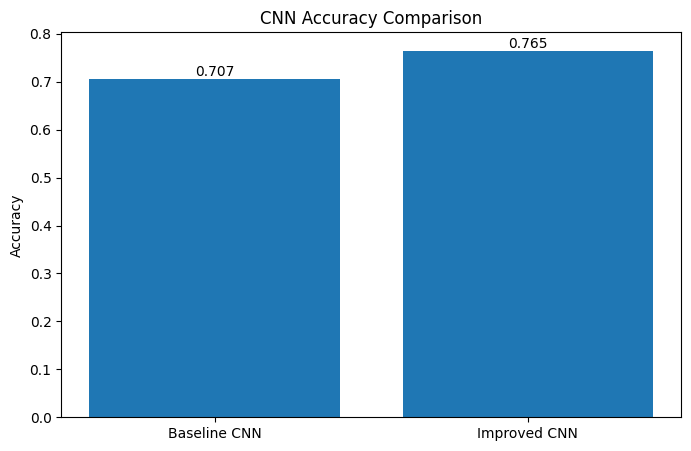

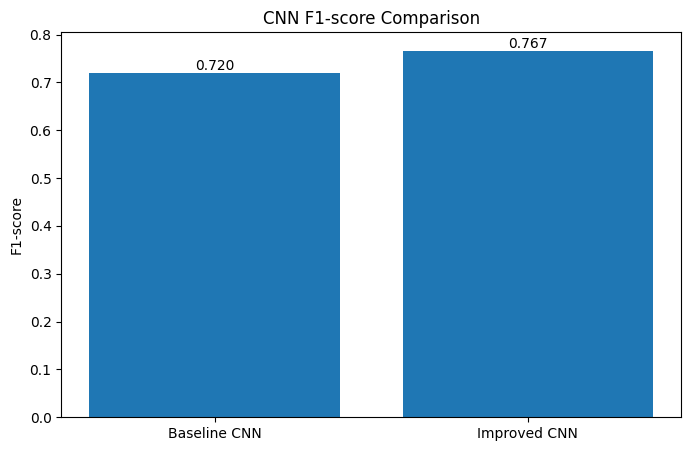

In [ ]:
# Compare CNN Models

models = ["Baseline CNN", "Improved CNN"]
accuracies = [baseline_acc, improved_acc]
f1_scores = [baseline_f1, improved_f1]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("CNN Accuracy Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)
plt.title("CNN F1-score Comparison")
plt.ylabel("F1-score")

for i, v in enumerate(f1_scores):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

The tuned 1D CNN achieved the best performance among all models, with an accuracy of 0.765 and an F1-score of 0.767. Compared to the baseline CNN, this represents a substantial improvement, demonstrating the importance of architectural design and training strategies in deep learning models. The use of batch normalization, global average pooling, and early stopping contributed to better generalization and reduced overfitting. These results highlight that deep learning models, when properly tuned, are highly effective for EEG classification tasks and outperform traditional machine learning approaches based on handcrafted features.

In [ ]:
# Bandpower Feature Extraction

import numpy as np
from scipy.signal import welch

# Sampling frequency
# Change this if your dataset uses a different sampling rate
fs = 250

# EEG frequency bands
bands = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "mu": (8, 12),
    "beta": (13, 30),
    "gamma": (30, 45)
}

def compute_bandpower_features(X, fs, bands):
    """
    X shape: (samples, channels, timepoints)
    Returns: (samples, channels * number_of_bands)
    """
    features = []

    for trial in X:
        trial_features = []

        for channel_signal in trial:
            freqs, psd = welch(channel_signal, fs=fs, nperseg=256)

            for band_name, (low, high) in bands.items():
                band_mask = (freqs >= low) & (freqs <= high)
                band_power = np.trapz(psd[band_mask], freqs[band_mask])
                trial_features.append(band_power)

        features.append(trial_features)

    return np.array(features)

X_train_bandpower = compute_bandpower_features(X_train, fs, bands)
X_val_bandpower = compute_bandpower_features(X_val, fs, bands)

print("Bandpower train shape:", X_train_bandpower.shape)
print("Bandpower val shape:", X_val_bandpower.shape)

/tmp/ipykernel_11696/8745480.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(psd[band_mask], freqs[band_mask])


Bandpower train shape: (2944, 30)
Bandpower val shape: (736, 30)


In [ ]:
# Scale Bandpower Features

from sklearn.preprocessing import StandardScaler

scaler_band = StandardScaler()

X_train_bandpower_scaled = scaler_band.fit_transform(X_train_bandpower)
X_val_bandpower_scaled = scaler_band.transform(X_val_bandpower)

print("Bandpower features scaled successfully.")

Bandpower features scaled successfully.


In [ ]:
# Random Forest with Bandpower Features

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_band = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_band.fit(X_train_bandpower_scaled, y_train)
y_pred_rf_band = rf_band.predict(X_val_bandpower_scaled)

print("Random Forest (Bandpower Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_band))
print("Precision:", precision_score(y_val, y_pred_rf_band))
print("Recall:", recall_score(y_val, y_pred_rf_band))
print("F1-score:", f1_score(y_val, y_pred_rf_band))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf_band))

Random Forest (Bandpower Features)
Accuracy: 0.7065217391304348
Precision: 0.7087912087912088
Recall: 0.7010869565217391
F1-score: 0.7049180327868853
Confusion Matrix:
 [[262 106]
 [110 258]]


In [ ]:
# RBF SVM with Bandpower Features

from sklearn.svm import SVC

svm_rbf_band = SVC(kernel="rbf", C=1, gamma="scale")

svm_rbf_band.fit(X_train_bandpower_scaled, y_train)
y_pred_svm_band = svm_rbf_band.predict(X_val_bandpower_scaled)

print("RBF SVM (Bandpower Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_svm_band))
print("Precision:", precision_score(y_val, y_pred_svm_band))
print("Recall:", recall_score(y_val, y_pred_svm_band))
print("F1-score:", f1_score(y_val, y_pred_svm_band))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_svm_band))

RBF SVM (Bandpower Features)
Accuracy: 0.6698369565217391
Precision: 0.6790830945558739
Recall: 0.6440217391304348
F1-score: 0.6610878661087866
Confusion Matrix:
 [[256 112]
 [131 237]]


In [ ]:
# Combine Improved Statistical + Bandpower Features


X_train_combined = np.concatenate([X_train_stats, X_train_bandpower_scaled], axis=1)
X_val_combined = np.concatenate([X_val_stats, X_val_bandpower_scaled], axis=1)

print("Combined train shape:", X_train_combined.shape)
print("Combined val shape:", X_val_combined.shape)

Combined train shape: (2944, 78)
Combined val shape: (736, 78)


In [ ]:
# Random Forest with Combined Features

rf_combined = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_combined.fit(X_train_combined, y_train)
y_pred_rf_combined = rf_combined.predict(X_val_combined)

print("Random Forest (Statistical + Bandpower Features)")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_combined))
print("Precision:", precision_score(y_val, y_pred_rf_combined))
print("Recall:", recall_score(y_val, y_pred_rf_combined))
print("F1-score:", f1_score(y_val, y_pred_rf_combined))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf_combined))

Random Forest (Statistical + Bandpower Features)
Accuracy: 0.7323369565217391
Precision: 0.7317073170731707
Recall: 0.7336956521739131
F1-score: 0.7327001356852103
Confusion Matrix:
 [[269  99]
 [ 98 270]]


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step


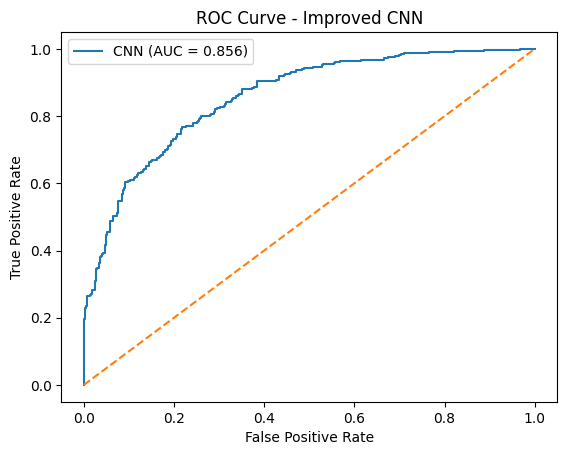

AUC Score: 0.8564213137996219


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities from BEST CNN
y_prob = improved_cnn.predict(X_val_cnn)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Improved CNN")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

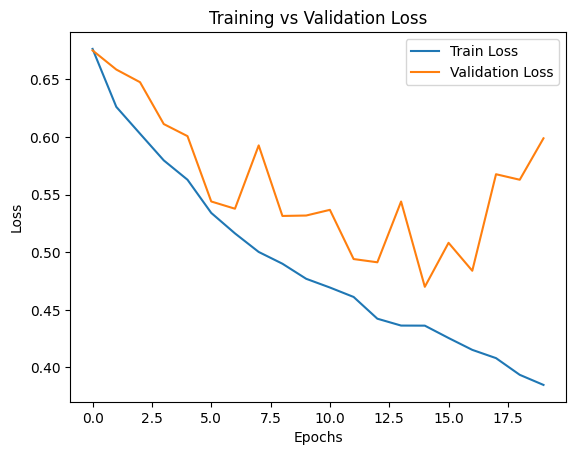

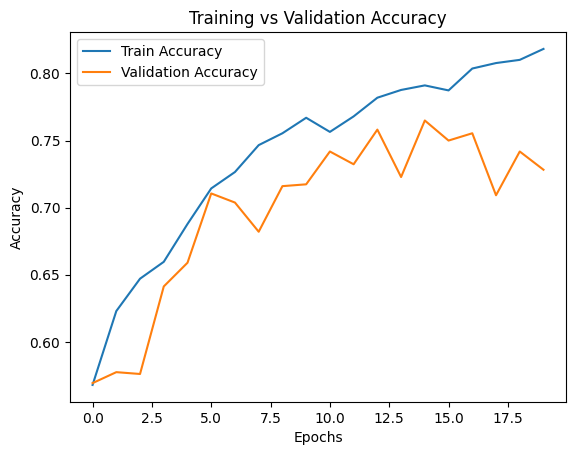

In [ ]:
# Plot training curves

plt.figure()
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Get predictions
y_pred = (y_prob > 0.5).astype(int).flatten()

# Find misclassified samples
misclassified = np.where(y_val != y_pred)[0]

print("Total samples:", len(y_val))
print("Misclassified:", len(misclassified))

# False Positives and False Negatives
fp = np.sum((y_pred == 1) & (y_val == 0))
fn = np.sum((y_pred == 0) & (y_val == 1))

print("False Positives:", fp)
print("False Negatives:", fn)

Total samples: 736
Misclassified: 173
False Positives: 89
False Negatives: 84


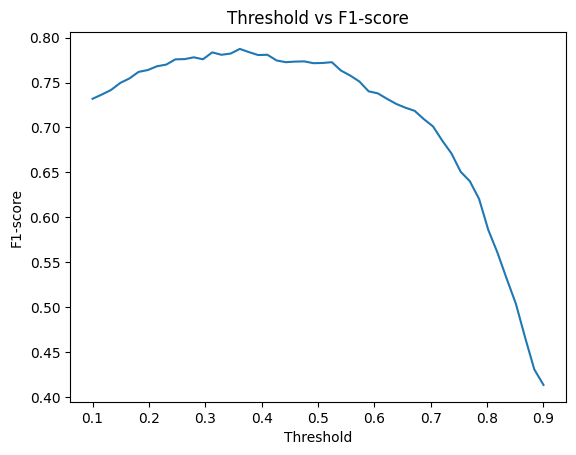

Best threshold: 0.36122448979591837


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.show()

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_t)

Model Validation and Analysis

To further evaluate the performance of the tuned CNN, multiple validation techniques were applied. The ROC curve achieved an AUC of 0.856, indicating strong discriminative capability between the two classes. This confirms that the model performs well across a range of classification thresholds, not just at a fixed decision boundary.

Analysis of the training and validation curves showed stable learning behavior with only mild overfitting. While training loss continued to decrease, validation loss stabilized and exhibited slight fluctuations, suggesting that the model generalizes well to unseen data. Similarly, the small gap between training and validation accuracy indicates good generalization performance.

Threshold analysis revealed that the optimal classification threshold differs from the default value of 0.5, with peak F1-score achieved at a lower threshold. This demonstrates the importance of threshold tuning in improving classification performance.

Finally, error analysis showed a balanced distribution of false positives and false negatives, indicating that the model does not exhibit bias toward either class. Overall, these analyses confirm that the model is both accurate and reliable.

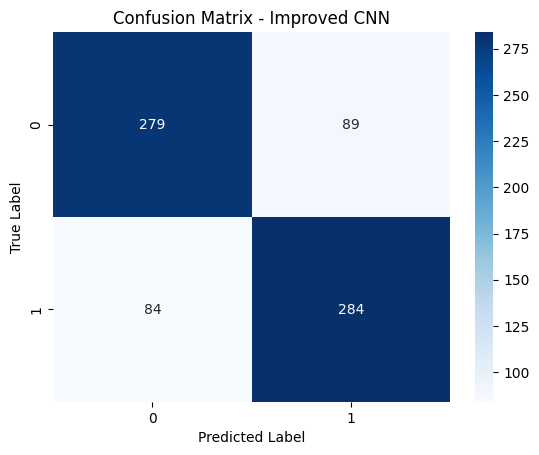

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Improved CNN")
plt.show()

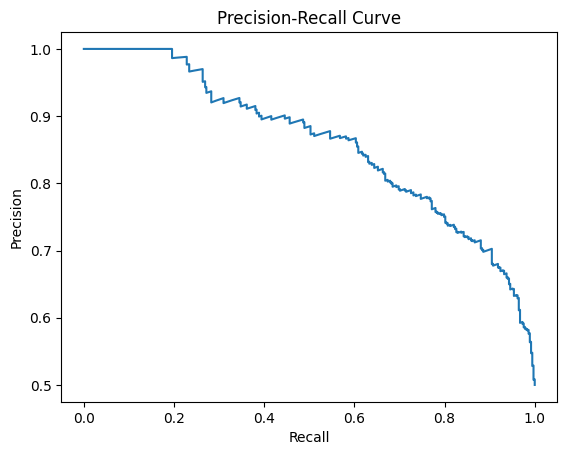

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

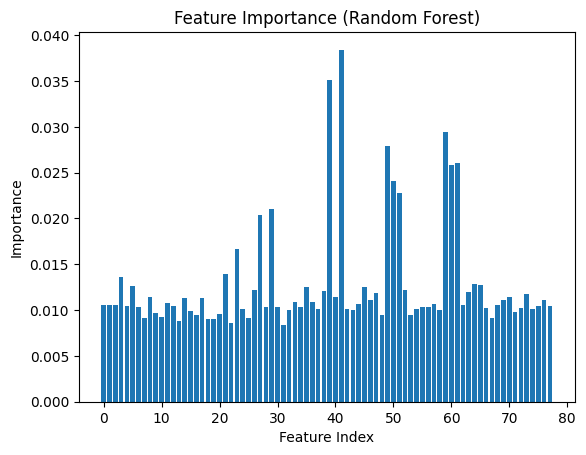

In [ ]:
import numpy as np

importances = rf_combined.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

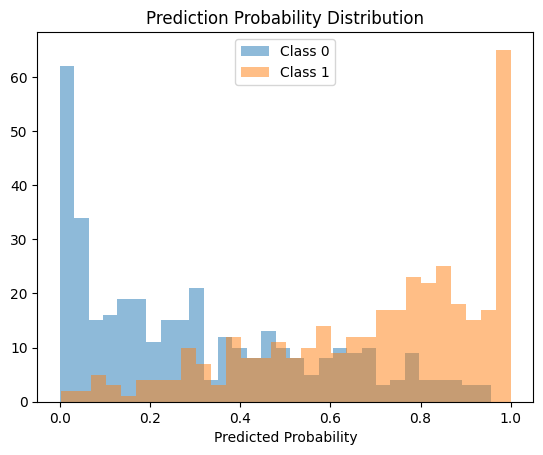

In [ ]:
plt.figure()
plt.hist(y_prob[y_val==0], bins=30, alpha=0.5, label="Class 0")
plt.hist(y_prob[y_val==1], bins=30, alpha=0.5, label="Class 1")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "LogReg (Flatten)",
        "LogReg (Mean/Var)",
        "LogReg (Improved Stats)",

        "Linear SVM (Flatten)",
        "Linear SVM (Mean/Var)",
        "Linear SVM (Improved Stats)",

        "RBF SVM (Flatten)",
        "RBF SVM (Mean/Var)",
        "RBF SVM (Improved Stats)",

        "Random Forest (Stats)",
        "Random Forest (Bandpower)",
        "Random Forest (Stats + Bandpower)",

        "1D CNN (Baseline)",
        "1D CNN (Improved) ⭐"
    ],

    "Accuracy": [
        0.6970,
        0.5774,
        0.6413,

        0.6753,
        0.5584,
        0.6427,

        0.7133,
        0.5503,
        0.6549,

        0.6700,
        0.7065,
        0.7323,

        0.7065,
        0.7649
    ],

    "F1 Score": [
        0.6991,
        0.5662,
        0.6229,

        0.6766,
        0.5053,
        0.6127,

        0.7168,
        0.4962,
        0.6511,

        0.6712,
        0.7049,
        0.7327,

        0.7195,
        0.7665
    ]
})

print(final_results.sort_values(by="Accuracy", ascending=False))

                                Model  Accuracy  F1 Score
13                1D CNN (Improved) ⭐    0.7649    0.7665
11  Random Forest (Stats + Bandpower)    0.7323    0.7327
6                   RBF SVM (Flatten)    0.7133    0.7168
10          Random Forest (Bandpower)    0.7065    0.7049
12                  1D CNN (Baseline)    0.7065    0.7195
0                    LogReg (Flatten)    0.6970    0.6991
3                Linear SVM (Flatten)    0.6753    0.6766
9               Random Forest (Stats)    0.6700    0.6712
8            RBF SVM (Improved Stats)    0.6549    0.6511
5         Linear SVM (Improved Stats)    0.6427    0.6127
2             LogReg (Improved Stats)    0.6413    0.6229
1                   LogReg (Mean/Var)    0.5774    0.5662
4               Linear SVM (Mean/Var)    0.5584    0.5053
7                  RBF SVM (Mean/Var)    0.5503    0.4962
